# Импорт библиотек

In [292]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import numpy as np

from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [293]:
plt.style.use("seaborn-v0_8")
sns.set_palette("tab10")

In [294]:
df_2015 = pd.read_excel("data/result2015.xlsx")
df_2015.columns = (
    df_2015.columns
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

In [295]:
df_2020 = pd.read_excel("data/result2020.xlsx")
df_2020.columns = (
    df_2020.columns
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

In [296]:
df_2021 = pd.read_excel("data/result2021.xlsx")
df_2021.columns = (
    df_2021.columns
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

In [297]:
df_2022 = pd.read_excel("data/result2022.xlsx")
df_2022.columns = (
    df_2022.columns
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

# EDA

Сразу нормализуем названия столбцов

In [298]:
col_rename = {
    "Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы РФ": "ege_avg_budget_full_time",
    "Средний балл ЕГЭ студентов университета, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы Российской Федерации, за исключением лиц, поступивших с учетом особых прав и в рамках квоты целевого приема": "ege_avg_budget_full_time_no_special_rights_no_target_quota",
    "Средний балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме по программам бакалавриата и специалитета с оплатой стоимости затрат на обучение физическими и юридическими лицами": "ege_avg_paid_full_time",
    "Усредненный по реализуемым направлениям (специальностям) минимальный балл ЕГЭ студентов, принятых по результатам ЕГЭ на обучение по очной форме на программы бакалавриата и специалитета": "ege_min_avg_full_time",
    "Численность студентов, победителей и призеров заключительного этапа всероссийской олимпиады школьников, членов сборных команд Российской Федерации, участвовавших в международных олимпиадах по общеобразовательным предметам по специальностям и (или) направлениям подготовки, соответствующим профилю всероссийской олимпиады школьников или международной олимпиады, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета без вступительных испытаний": "olympiad_final_winners_admitted_no_exams",
    "Численность студентов, победителей и призеров олимпиад школьников, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета по специальностям и (или) направлениям подготовки, соответствующим профилю олимпиады школьников, без вступительных испытаний": "school_olympiad_winners_admitted_no_exams",
    "Численность студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета": "target_admission_count_full_time",
    "Удельный вес численности студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета в общей численности студентов, принятых на первый курс по программам бакалавриата и специалитета на очную форму обучения": "target_admission_share_full_time",
    "Удельный вес численности студентов (приведенного контингента), обучающихся по программам магистратуры, в общей численности приведенного контингента обучающихся по образовательным программам бакалавриата, специалитета и магистратуры": "masters_share_in_total_contingent",
    "Удельный вес численности обучающихся (приведенного контингента), по программам магистратуры, подготовки научно-педагогических кадров в аспирантуре (адъюнктуре), ординатуры, ассистентуры-стажировки в общей численности приведенного контингента обучающихся по основным образовательным программам высшего образования": "postgrad_and_residency_share_in_total_contingent",
    "Удельный вес численности студентов, имеющих диплом бакалавра, специалиста или магистра других организаций, принятых на первый курс на обучение по программам магистратуры образовательной организации, в общей численности студентов, принятых на первый курс по программам магистратуры на очную форму обучения": "masters_admitted_from_other_orgs_share_full_time",
    "Удельный вес численности обучающихся по программам магистратуры, подготовки научно-педагогических кадров в аспирантуре (адъюнктуре), ординатуры, ассистентуры-стажировки, имеющих диплом бакалавра, диплом специалиста или диплом магистра других организаций в общей численности обучающихся по программам магистратуры, подготовки научно-педагогических кадров в аспирантуре (адъюнктуре), ординатуры, ассистентуры-стажировки": "postgrad_from_other_orgs_share",
    "Численность аспирантов (адъюнктов), ординаторов, ассистентов-стажеров образовательной организации в расчете на 100 студентов (приведенного контингента)": "postgrad_per_100_students",
    "Удельный вес численности слушателей из сторонних организаций в общей численности слушателей, прошедших обучение в образовательной организации по программам повышения квалификации или профессиональной переподготовки": "dpo_external_listeners_share",
    "Удельный вес численности студентов, обучающихся по направлениям подготовки бакалавриата, специалитета, и магистратуры по областям знаний «Инженерное дело, технологии и технические науки», «Здравоохранение и медицинские науки», «Образование и педагогические науки», с которыми заключены договоры о целевом обучении, в общей численности студентов, обучающихся по указанным областям знаний": "target_contract_share_priority_fields",
    "Удельный вес численности обучающихся (приведенного контингента), по программам магистратуры и подготовки научно-педагогических кадров в аспирантуре в общей численности приведенного контингента обучающихся по основным образовательным программам высшего образования":
        "share_of_masters_and_postgraduate_students_in_total_higher_education_enrollment",
    "Удельный вес численности обучающихся по программам магистратуры и подготовки научно-педагогических кадров в аспирантуре, имеющих диплом бакалавра, диплом специалиста или диплом магистра других организаций в общей численности обучающихся по программам магистратуры и подготовки научно-педагогических кадров в аспирантуре":
        "share_of_masters_and_postgraduate_students_with_external_degrees",
    "Численность аспирантов образовательной организации в расчете на 100 студентов (приведенного контингента)":
        "postgraduate_students_per_100_students",
    "Количество цитирований публикаций, изданных за последние 5 лет, индексируемых в информационно-аналитической системе научного цитирования Web of Science в расчете на 100 НПР":
        "wos_citations_last_5_years_per_100_faculty",
    "Количество цитирований публикаций, изданных за последние 5 лет, индексируемых в информационно-аналитической системе научного цитирования Scopus в расчете на 100 НПР":
        "scopus_citations_last_5_years_per_100_faculty",
    "Количество цитирований публикаций, изданных за последние 5 лет, индексируемых в Российском индексе научного цитирования (далее – РИНЦ) в расчете на 100 НПР":
        "rinc_citations_last_5_years_per_100_faculty",
    "Число публикаций организации, индексируемых в информационно-аналитической системе научного цитирования Web of Science, в расчете на 100 НПР":
        "wos_publications_per_100_faculty",
    "Число публикаций организации, индексируемых в информационно-аналитической системе научного цитирования Scopus, в расчете на 100 НПР":
        "scopus_publications_per_100_faculty",
    "Число публикаций организации, индексируемых в информационно-аналитической системе научного цитирования РИНЦ, в расчете на 100 НПР":
        "rinc_publications_per_100_faculty",
    "Доходы от НИОКР (за исключением средств бюджетов бюджетной системы Российской Федерации, государственных фондов поддержки науки) в расчете на одного НПР":
        "r_and_d_income_per_faculty_excluding_budget_funds",
    "Удельный вес численности НПР без ученой степени – до 30 лет, кандидатов наук – до 35 лет, докторов наук – до 40 лет, в общей численности НПР":
        "share_of_young_faculty_without_degree_or_with_scientific_degree",
    "Количество полученных грантов за отчетный год в расчете на 100 НПР":
        "grants_received_per_100_faculty",
    "Численность зарубежных ведущих профессоров, преподавателей и исследователей, работающих в образовательной организации не менее 1 семестра":
        "number_of_foreign_leading_professors_and_researchers",
    "Удельный вес численности иностранных граждан (кроме стран СНГ) из числа аспирантов образовательной организации в общей численности аспирантов":
        "share_of_non_cis_foreign_postgraduates",
    "Удельный вес численности иностранных граждан из стран СНГ из числа аспирантов образовательной организации в общей численности аспирантов":
        "share_of_cis_foreign_postgraduates",
    "Объем средств, полученных образовательной организацией на выполнение НИОКР от иностранных граждан и иностранных юридических лиц":
        "foreign_r_and_d_funding_volume",
    "Общий объем НИОКР, выполненных собственными силами":
        "total_r_and_d_volume_internal",
    "Общий объем работ, услуг, связанных с научными, научно-техническими, творческими услугами и разработками, выполненных собственными силами":
        "total_scientific_and_technical_services_volume_internal",
    "Общая численность аспирантов":
        "total_number_of_postgraduates",
    "Доля аспирантов, обучающихся в очной форме":
        "share_of_full_time_postgraduates",
    "Общая численность иностранных аспирантов":
        "total_number_of_foreign_postgraduates",
    "Количество цитирований публикаций, изданных за последние 5 лет, индексируемых в информационно-аналитической системе научного цитирования Web of Science Core Collection в расчете на 100 НПР":
        "wos_core_collection_citations_last_5_years_per_100_faculty",
    "Число публикаций организации, индексируемых в информационно-аналитической системе научного цитирования Web of Science Core Collection, в расчете на 100 НПР":
        "wos_core_collection_publications_per_100_faculty",

    "Количество цитирований публикаций, изданных за последние 5 лет, индексируемых в информационно-аналитической системе научного цитирования Web of Science Core Collection в расчете на 100 НПР[н]": "citations_wos_5y_per_100_faculty",
    "Количество цитирований публикаций, изданных за последние 5 лет, индексируемых в информационно-аналитической системе научного цитирования Scopus в расчете на 100 НПР[н]": "citations_scopus_5y_per_100_faculty",
    "Количество цитирований публикаций, изданных за последние 5 лет, индексируемых в Российском индексе научного цитирования (далее – РИНЦ) в расчете на 100 НПР[н]": "citations_rinc_5y_per_100_faculty",
    "Число публикаций организации, индексируемых в информационно-аналитической системе научного цитирования Web of Science Core Collection, в расчете на 100 НПР[н]": "publications_wos_per_100_faculty",
    "Число публикаций организации, индексируемых в информационно-аналитической системе научного цитирования Scopus, в расчете на 100 НПР[н]": "publications_scopus_per_100_faculty",
    "Число публикаций организации, индексируемых в информационно-аналитической системе научного цитирования РИНЦ, в расчете на 100 НПР[н]": "publications_rinc_per_100_faculty",
    "Общий объем научно-исследовательских и опытно-конструкторских работ (далее – НИОКР)": "rnd_total_volume",
    "Удельный вес доходов от НИОКР в общих доходах образовательной организации": "rnd_income_share_total",
    "Удельный вес НИОКР, выполненных собственными силами (без привлечения соисполнителей), в общих доходах образовательной организации от НИОКР": "rnd_own_work_share_in_rnd_income",
    "Доходы от НИОКР (за исключением средств бюджетов бюджетной системы Российской Федерации, государственных фондов поддержки науки) в расчете на одного НПР[н]": "rnd_income_per_faculty_excl_budget",
    "Количество лицензионных соглашений": "license_agreements_count",
    "Удельный вес средств, полученных образовательной организацией от использования результатов интеллектуальной деятельности, в общих доходах образовательной организации": "rid_income_share_total",
    "Удельный вес численности НПР без ученой степени – до 30 лет, кандидатов наук – до 35 лет, докторов наук – до 40 лет, в общей численности НПР[н]": "young_faculty_share",
    "Удельный вес научно-педагогических работников, защитивших кандидатские и докторские диссертации за отчетный период в общей численности НПР": "defended_theses_share",
    "Количество научных журналов, в том числе электронных, издаваемых образовательной организацией": "journals_count",
    "Количество полученных грантов за отчетный год в расчете на 100 НПР[н]": "grants_per_100_faculty",

    "Удельный вес численности иностранных студентов (кроме стран Содружества Независимых Государств (далее – СНГ)), обучающихся программам бакалавриата, специалитета, магистратуры, в общей численности студентов (приведенный контингент)": "foreign_students_non_cis_share",
    "Удельный вес численности иностранных студентов из СНГ, обучающихся по программам бакалавриата, специалитета, магистратуры, в общей численности студентов (приведенный контингент)": "foreign_students_cis_share",
    "Удельный вес численности иностранных студентов, завершивших освоение образовательных программ бакалавриата, специалитета, магистратуры, в общей численности студентов (приведенный контингент)": "foreign_graduates_share",
    "Удельный вес численности иностранных студентов (кроме стран СНГ), завершивших освоение образовательных программ бакалавриата, программ специалитета, программ магистратуры, в общей численности студентов (приведенный контингент)": "foreign_graduates_non_cis_share",
    "Удельный вес численности иностранных студентов из стран СНГ, завершивших освоение образовательных программ бакалавриата, программ специалитета, программ магистратуры, в общей численности студентов (приведенный контингент)": "foreign_graduates_cis_share",
    "Удельный вес численности студентов, обучающихся по очной форме обучения по образовательным программам бакалавриата, программам специалитета, программам магистратуры, прошедших обучение за рубежом не менее семестра (триместра), в общей численности студентов, обучающихся по очной форме обучения": "outbound_mobility_semester_share",
    "Численность студентов иностранных образовательных организаций, прошедших обучение в образовательной организации по образовательным по очной форме обучения по образовательным программам бакалавриата, программам специалитета, программам магистратуры, не менее семестра (триместра) в расчете на 100 студентов, обучающихся по очной форме обучения": "inbound_mobility_per_100_students",
    "Удельный вес численности иностранных граждан из числа НПР в общей численности НПР": "foreign_faculty_share",
    "Численность зарубежных ведущих профессоров, преподавателей и исследователей, работающих (работавших) в образовательной организации не менее 1 семестра": "visiting_professors_count",
    "Удельный вес численности иностранных граждан (кроме стран СНГ) из числа аспирантов (адъюнктов), ординаторов, ассистентов-стажеров образовательной организации в общей численности аспирантов (адъюнктов), ординаторов, ассистентов-стажеров": "foreign_postgrad_non_cis_share",
    "Удельный вес численности иностранных граждан из стран СНГ из числа аспирантов (адъюнктов), ординаторов, ассистентов-стажеров образовательной организации в общей численности аспирантов (адъюнктов), ординаторов, ассистентов-стажеров": "foreign_postgrad_cis_share",
    "Объем средств, полученных образовательной организацией от выполнения НИОКР от иностранных граждан и иностранных юридических лиц": "rnd_funds_from_foreign_entities",
    "Объем средств от образовательной деятельности, полученных образовательной организацией от иностранных граждан и иностранных юридических лиц": "edu_funds_from_foreign_entities",

    "Доходы образовательной организации из средств от приносящей доход деятельности в расчете на одного НПР": "income_nonbudget_per_faculty",
    "Доля доходов из средств от приносящей доход деятельности в доходах по всем видам финансового обеспечения (деятельности) образовательной организации": "income_nonbudget_share_total",
    "Отношение средней заработной платы НПР в образовательной организации (из всех источников) к средней заработной плате по экономике региона": "faculty_salary_to_region_avg_ratio",
    "Доходы образовательной организации из всех источников в расчете на численность студентов (приведенный контингент)": "income_per_student",
    "Общая площадь учебно-лабораторных помещений в расчете на одного студента (приведенного контингента),в том числе:": "teaching_lab_area_per_student_total",
    "имеющихся на праве собственности": "teaching_lab_area_owned",
    "закрепленных на праве оперативного управления": "teaching_lab_area_operational",
    "предоставленных в безвозмездное пользование": "teaching_lab_area_free_use",
    "предоставленных в аренду": "teaching_lab_area_rented",
    "Количество персональных компьютеров в расчете на одного студента (приведенного контингента)": "pcs_per_student",
    "Удельный вес стоимости машин и оборудования (не старше 5 лет) в общей стоимости машин и оборудования": "equipment_under_5y_value_share",
    "Количество экземпляров печатных учебных изданий (включая учебники и учебные пособия) из общего количества единиц хранения библиотечного фонда, состоящих на учете, в расчете на одного студента (приведенного контингента)": "printed_textbooks_per_student",
    "Удельный вес НПР, имеющих ученую степень кандидата наук, в общей численности НПР": "faculty_phd_share",
    "Удельный вес НПР имеющих ученую степень доктора наук, в общей численности НПР": "faculty_dsc_share",
    "Удельный вес НПР, имеющих ученую степень кандидата и доктора наук, в общей численности НПР образовательной организации (без совместителей и работающих по договорам гражданско-правового характера)": "faculty_phd_dsc_share",
    "Число НПР, имеющих ученую степень кандидата и доктора наук, в расчете на 100 студентов": "faculty_phd_dsc_per_100_students",
    "Доля штатных работников ППС в общей численности ППС": "faculty_staff_share",

    "2": "section_2",
    "Образовательная деятельность": "section_education",
    "Общая численность студентов, обучающихся по программам бакалавриата, специалитета, магистратуры": "students_total",
    "в том числе:по очной форме обучения": "students_full_time",
    "по очно-заочной (вечерней) форме обучения": "students_part_time_evening",
    "по заочной форме обучения": "students_correspondence",
    "Средний балл ЕГЭ студентов, принятых на обучение по программам бакалавриата и специалитета, по всем формам обучения": "ege_avg_all_forms",
    "Доля обучающихся по программам бакалавриата, специалитета, магистратуры в очной форме": "share_full_time",
    "Доля обучающихся по программам бакалавриата в общей численности обучающихся по программам бакалавриата, специалитета, магистратуры": "share_bachelor_in_total",
    "Доля обучающихся по программам магистратуры в общей численности обучающихся по программам бакалавриата, специалитета, магистратуры": "share_master_in_total",
    "Общая численность слушателей программ дополнительного профессионального образования": "dpo_listeners_total",
    "Общая численность обучающихся по программам среднего профессионального образования": "spo_students_total",
    "Число предприятий, с которыми заключены договоры на подготовку специалистов": "partner_enterprises_count",
    "Число предприятий, являющихся базами практики, с которыми оформлены договорные отношения": "practice_bases_count",

    "Научная деятельность": "section_research",
    "Общий объем средств, поступивших (за отчетный год) от выполнения НИОКР, выполненных собственными силами": "rnd_funds_own_total",
    "Общий объем средств, поступивших (за отчетный год) от выполнения работ, услуг, связанных с научными, научно-техническими, творческими услугами и разработками, выполненных собственными силами": "research_services_funds_own_total",
    "Общее количество публикаций организации в расчете на 100 НПР": "publications_total_per_100_faculty",
    "Количество бизнес-инкубаторов": "incubators_count",
    "Количество технопарков": "technoparks_count",
    "Количество центров коллективного пользования научным оборудованием": "shared_equipment_centers_count",
    "Количество малых предприятий": "small_enterprises_count",
    "Общая численность аспирантов (адъюнктов), интернов, ординаторов, ассистентов-стажеров": "postgrads_total",
    "Доля аспирантов (адъюнктов), интернов, ординаторов, ассистентов-стажеров, обучающихся в очной форме": "postgrads_full_time_share",
    "Общая численность докторантов": "doctoral_students_total",
    "Число диссертационных советов": "dissertation_councils_count",

    "Кадровый потенциал": "section_hr",
    "Общая численность работников образовательной организации (без внешних совместителей и работающих по договорам ГПХ)": "employees_total",
    "Общая численность ППС (без внешних совместителей и работающих по договорам ГПХ)": "faculty_total",
    "Общая численность научных работников (без внешних совместителей и работающих по договорам ГПХ)": "researchers_total",
    "Доля ППС, имеющих ученые степени": "faculty_degree_share",
    "Доля научных работников, имеющих ученые степени": "researchers_degree_share",
    "Доля ППС возрастной категории моложе 65 лет": "faculty_under_65_share",
    "Доля ППС возрастной категории моложе 40 лет": "faculty_under_40_share",
    "Средняя заработная плата ППС (без внешних совместителей и работающих по договорам ГПХ)": "faculty_avg_salary",
    "Средняя заработная плата научных работников (без внешних совместителей и работающих по договорам ГПХ)": "researchers_avg_salary",

    "Международная деятельность": "section_international",
    "Общая численность иностранных студентов, обучающихся по программам бакалавриата, специалитета, магистратуры": "foreign_students_total",
    "Доля иностранных студентов в общей численности студентов, обучающихся по программам бакалавриата, специалитета, магистратуры": "foreign_students_share_total",
    "Общее число образовательных программ высшего образования, реализуемых совместно с зарубежными вузами и ведущих к получению двух дипломов": "double_degree_programs_count",
    "Общая численность обучающихся по очной форме обучения по программам бакалавриата, специалитета, магистратуры, реализуемым совместно с зарубежными вузами и ведущим к получению двух дипломов": "double_degree_students_full_time_total",
    "Общая численность иностранных аспирантов (адъюнктов), интернов, ординаторов, ассистентов-стажеров": "foreign_postgrads_total",
    "Число статей, подготовленных совместно с зарубежными организациями": "intl_coauthored_articles_count",
    "Доходы вуза из иностранных источников на выполнение НИОКР": "rnd_income_foreign_sources",
    "Доходы вуза от образовательной деятельности из иностранных источников": "edu_income_foreign_sources",
    "Количество созданных результатов интеллектуальной деятельности, имеющих правовую охрану за пределами России": "rid_protected_abroad_count",

    "Инфраструктура": "section_infrastructure",
    "Общая площадь зданий (помещений)": "buildings_area_total",
    "Площадь учебно-лабораторных зданий": "teaching_lab_buildings_area",
    "Площадь, предназначенная для научно-исследовательских подразделений": "research_units_area",
    "Площадь общежитий": "dorms_area",
    "Площадь крытых спортивных сооружений": "indoor_sports_area",
    "Доля студентов, не обеспеченных собственным общежитием, в числе студентов, нуждающихся в общежитии": "dorm_shortage_share",
    "Количество персональных компьютеров": "pcs_total",
    "Доля персональных компьютеров, имеющих доступ к Интернету": "pcs_internet_share",
    "Наличие электронной библиотечной системы": "has_e_library_system",

    "Финансово-экономическая деятельность": "section_finance",
    "Доходы вуза из всех источников": "income_total",
    "Доходы вуза из внебюджетных источников": "income_nonbudget",
    "Доля доходов вуза из внебюджетных источников": "income_nonbudget_share",
    "Доля доходов вуза из федерального бюджета": "income_federal_budget_share",
    "Доля доходов вуза из бюджета субъекта РФ и местного бюджета": "income_regional_local_budget_share",
    "Доля доходов вуза от образовательной деятельности в общих доходах вуза": "income_edu_share_total",
    "Доля доходов вуза от научных исследований и разработок в общих доходах вуза": "income_research_share_total",
    "Доля внебюджетных средств в доходах от образовательной деятельности": "nonbudget_share_in_edu_income",
    "Доля внебюджетных средств в доходах от научных исследований и разработок": "nonbudget_share_in_research_income",

    "VUZ": "vuz",
    "Region": "region",
    "Type": "type",
    "Site": "site",
    "ID": "id",
    "year": "year",
}

In [299]:
df_2015 = df_2015.rename(columns=col_rename)
df_2020 = df_2020.rename(columns=col_rename)
df_2021 = df_2021.rename(columns=col_rename)
df_2022 = df_2022.rename(columns=col_rename)

In [300]:
df_2015["year"] = 2015
df_2020["year"] = 2020
df_2021["year"] = 2021
df_2022["year"] = 2022

In [301]:
df = pd.concat([df_2015, df_2020, df_2021, df_2022], ignore_index=True)

In [302]:
df.year = df.year.astype("category")

In [303]:
df.columns

Index(['ege_avg_budget_full_time',
       'ege_avg_budget_full_time_no_special_rights_no_target_quota',
       'ege_avg_paid_full_time', 'ege_min_avg_full_time',
       'olympiad_final_winners_admitted_no_exams',
       'school_olympiad_winners_admitted_no_exams',
       'target_admission_count_full_time', 'target_admission_share_full_time',
       'masters_share_in_total_contingent',
       'share_of_masters_and_postgraduate_students_in_total_higher_education_enrollment',
       ...
       'foreign_postgrads_total', 'citations_wos_5y_per_100_faculty',
       'citations_scopus_5y_per_100_faculty',
       'citations_rinc_5y_per_100_faculty', 'publications_wos_per_100_faculty',
       'publications_scopus_per_100_faculty',
       'publications_rinc_per_100_faculty',
       'rnd_income_per_faculty_excl_budget', 'young_faculty_share',
       'grants_per_100_faculty'],
      dtype='object', length=156)

In [304]:
df.shape

(2760, 156)

In [305]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2760 entries, 0 to 2759
Columns: 156 entries, ege_avg_budget_full_time to grants_per_100_faculty
dtypes: category(1), float64(116), int64(35), object(4)
memory usage: 3.3+ MB


## Пропуски

In [306]:
missing_info = df.isnull().sum()
missing_info = missing_info[missing_info > 0]
missing_info

share_of_masters_and_postgraduate_students_in_total_higher_education_enrollment    2048
share_of_masters_and_postgraduate_students_with_external_degrees                   2048
postgraduate_students_per_100_students                                             2048
wos_citations_last_5_years_per_100_faculty                                         2048
scopus_citations_last_5_years_per_100_faculty                                       681
rinc_citations_last_5_years_per_100_faculty                                         681
wos_publications_per_100_faculty                                                   2048
scopus_publications_per_100_faculty                                                 681
rinc_publications_per_100_faculty                                                   681
r_and_d_income_per_faculty_excluding_budget_funds                                   681
share_of_young_faculty_without_degree_or_with_scientific_degree                     681
grants_received_per_100_faculty 

In [307]:
missing_percent = (df.isnull().mean() * 100)
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

In [308]:
missing_percent

has_e_library_system                                                               100.000000
section_education                                                                  100.000000
publications_scopus_per_100_faculty                                                100.000000
publications_wos_per_100_faculty                                                   100.000000
citations_scopus_5y_per_100_faculty                                                100.000000
citations_wos_5y_per_100_faculty                                                   100.000000
section_finance                                                                    100.000000
section_infrastructure                                                             100.000000
section_international                                                              100.000000
section_hr                                                                         100.000000
section_research                                            

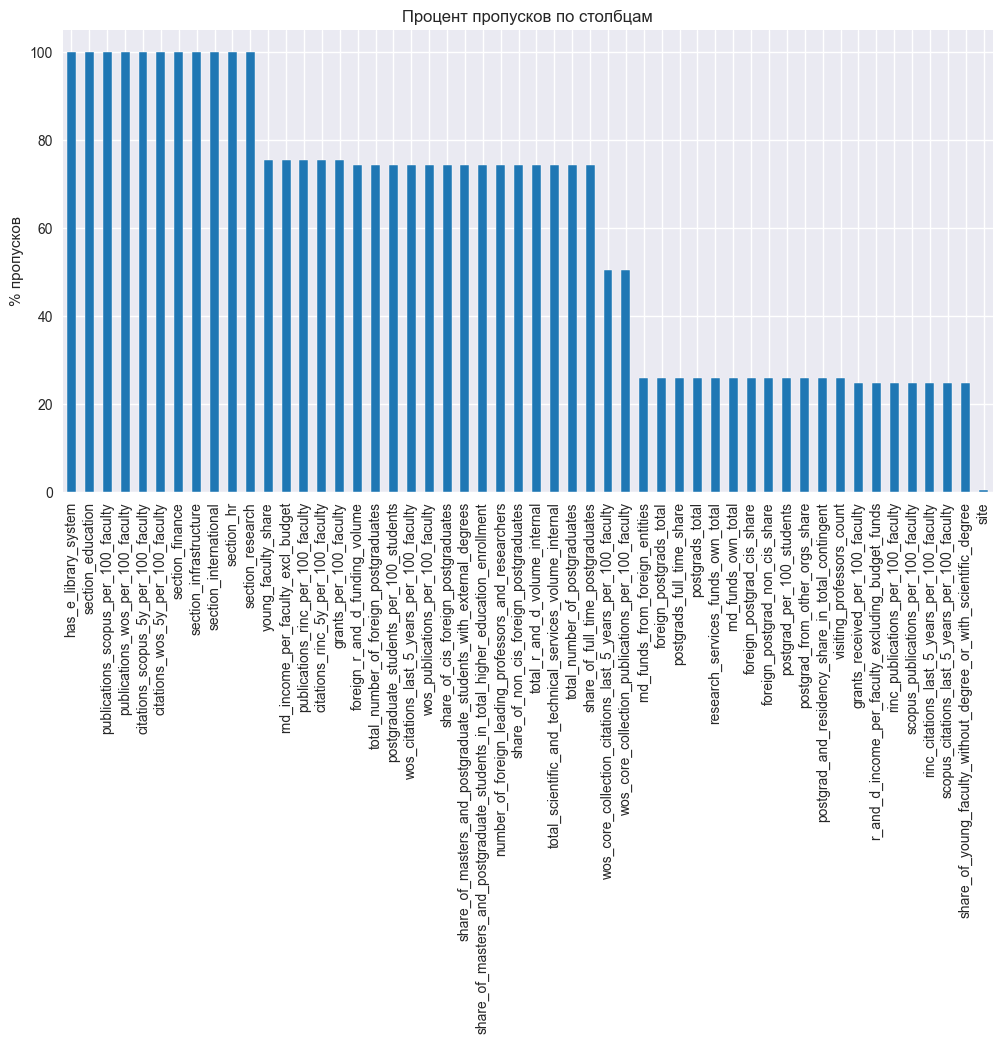

In [309]:
plt.figure(figsize=(12, 6))
missing_percent.plot(kind="bar")
plt.title("Процент пропусков по столбцам")
plt.ylabel("% пропусков")
plt.xticks(rotation=90)
plt.show()

Эти колонки мы удалим

In [310]:
missing_percent[missing_percent > 70].sort_values(ascending=False)

has_e_library_system                                                               100.000000
publications_scopus_per_100_faculty                                                100.000000
publications_wos_per_100_faculty                                                   100.000000
citations_scopus_5y_per_100_faculty                                                100.000000
citations_wos_5y_per_100_faculty                                                   100.000000
section_finance                                                                    100.000000
section_infrastructure                                                             100.000000
section_international                                                              100.000000
section_hr                                                                         100.000000
section_research                                                                   100.000000
section_education                                           

Вот эти пропуски нужно рассмотреть

In [311]:
missing_percent[missing_percent < 70].sort_values(ascending=False)

wos_core_collection_citations_last_5_years_per_100_faculty         50.471014
wos_core_collection_publications_per_100_faculty                   50.471014
foreign_postgrad_cis_share                                         25.797101
visiting_professors_count                                          25.797101
postgrad_and_residency_share_in_total_contingent                   25.797101
postgrad_per_100_students                                          25.797101
foreign_postgrad_non_cis_share                                     25.797101
postgrad_from_other_orgs_share                                     25.797101
rnd_funds_own_total                                                25.797101
research_services_funds_own_total                                  25.797101
postgrads_total                                                    25.797101
postgrads_full_time_share                                          25.797101
foreign_postgrads_total                                            25.797101

In [312]:
cols_under_70 = missing_percent[missing_percent < 70].index.tolist()

In [313]:
missing_by_year = (
    df
    .groupby("year")[cols_under_70]
    .apply(lambda x: x.isnull().mean() * 100)
)

In [314]:
missing_by_year = missing_by_year.T
missing_by_year["avg_missing_%"] = missing_by_year.mean(axis=1)
missing_by_year = missing_by_year.sort_values("avg_missing_%", ascending=False)

missing_by_year

year,2015,2020,2021,2022,avg_missing_%
wos_core_collection_citations_last_5_years_per_100_faculty,100.000000,0.000000,0.000000,100.0,50.000000
wos_core_collection_publications_per_100_faculty,100.000000,0.000000,0.000000,100.0,50.000000
share_of_young_faculty_without_degree_or_with_scientific_degree,0.000000,0.000000,0.000000,100.0,25.000000
scopus_citations_last_5_years_per_100_faculty,0.000000,0.000000,0.000000,100.0,25.000000
rinc_citations_last_5_years_per_100_faculty,0.000000,0.000000,0.000000,100.0,25.000000
scopus_publications_per_100_faculty,0.000000,0.000000,0.000000,100.0,25.000000
rinc_publications_per_100_faculty,0.000000,0.000000,0.000000,100.0,25.000000
r_and_d_income_per_faculty_excluding_budget_funds,0.000000,0.000000,0.000000,100.0,25.000000
grants_received_per_100_faculty,0.000000,0.000000,0.000000,100.0,25.000000
visiting_professors_count,100.000000,0.000000,0.000000,0.0,25.000000


Удалим все так как если нет полностью хотя бы одного признака для года, то кластеризация может плохо сработать. Они смогут разделяться по году, если их искуственно ввести, то может быть показана не настоящая ситуация.

In [315]:
df = df.drop(missing_percent[missing_percent > 0].index, axis=1)

In [316]:
df.shape

(2760, 104)

## Дубликаты

In [317]:
df.duplicated().sum()

0

## Константные признаки

In [318]:
const_cols = df.columns[df.nunique(dropna=False) == 1]
const_cols

Index(['section_2'], dtype='object')

Удалим эту колонку

In [319]:
df = df.drop(columns=const_cols)

Посмотрим и на квазиконстантные признаки

In [320]:
quasi_const_cols = []

for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).max()
    if top_freq > 0.95:
        quasi_const_cols.append(col)

quasi_const_cols

[]

## Уникальные признаки

In [321]:
unique_ratio = df.nunique() / len(df)
unique_ratio.sort_values(ascending=False).head(50)

income_total                                                  0.999275
income_nonbudget                                              0.998188
income_nonbudget_per_faculty                                  0.984058
income_per_student                                            0.974275
publications_total_per_100_faculty                            0.952536
printed_textbooks_per_student                                 0.941667
rnd_total_volume                                              0.912681
faculty_salary_to_region_avg_ratio                            0.898188
faculty_avg_salary                                            0.880072
students_total                                                0.857971
share_full_time                                               0.773913
income_edu_share_total                                        0.744203
students_full_time                                            0.738043
faculty_phd_dsc_share                                         0.730072
income

Уникальные признаки по годам

In [322]:
unique_by_year = (
    df.groupby("year")
    .nunique()
    .div(df.groupby("year").size(), axis=0)
)

unique_by_year.head()

,ege_avg_budget_full_time,ege_avg_budget_full_time_no_special_rights_no_target_quota,ege_avg_paid_full_time,ege_min_avg_full_time,olympiad_final_winners_admitted_no_exams,school_olympiad_winners_admitted_no_exams,target_admission_count_full_time,target_admission_share_full_time,masters_share_in_total_contingent,masters_admitted_from_other_orgs_share_full_time,...,income_federal_budget_share,income_regional_local_budget_share,income_edu_share_total,income_research_share_total,nonbudget_share_in_edu_income,nonbudget_share_in_research_income,vuz,region,type,id
year,,,,,,,,,,,,,,,,,,,,,
2015,0.671348,0.664326,0.811798,0.804775,0.025281,0.060393,0.268258,0.528090,0.595506,0.418539,...,0.723315,0.245787,0.905899,0.796348,0.764045,0.667135,1.0,0.123596,0.029494,1.0
2020,0.688953,0.686047,0.773256,0.771802,0.030523,0.069767,0.248547,0.533430,0.678779,0.520349,...,0.722384,0.250000,0.902616,0.755814,0.770349,0.603198,1.0,0.139535,0.031977,1.0
2021,0.708395,0.705449,0.776141,0.807069,0.035346,0.072165,0.257732,0.528719,0.714286,0.544919,...,0.786451,0.259205,0.914580,0.782032,0.782032,0.587629,1.0,0.141384,0.030928,1.0
2022,0.704846,0.701909,0.757709,0.779736,0.033774,0.076358,0.265786,0.555066,0.678414,0.414097,...,0.779736,0.261380,0.898678,0.795888,0.770925,0.609398,1.0,0.142438,0.030837,1.0


In [323]:
fully_unique_each_year = unique_by_year.columns[
    (unique_by_year == 1.0).all()
]

fully_unique_each_year

Index(['income_total', 'income_nonbudget', 'vuz', 'id'], dtype='object')

In [324]:
high_unique_each_year = unique_by_year.columns[
    (unique_by_year > 0.95).all()
]

high_unique_each_year

Index(['income_nonbudget_per_faculty', 'income_per_student',
       'printed_textbooks_per_student', 'publications_total_per_100_faculty',
       'buildings_area_total', 'teaching_lab_buildings_area', 'income_total',
       'income_nonbudget', 'vuz', 'id'],
      dtype='object')

Удалим технический индентификатор

In [325]:
df = df.drop(columns=["id"])

Уберем названия вузов

In [326]:
df = df.drop(columns=["vuz"])

Другие признаки имеют высокую уникальность – абсолютно нормально

## Описательная статистика

In [327]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns

### Числовые

In [328]:
num_summary = pd.DataFrame({
    "count": df[num_cols].count(),
    "missing_%": df[num_cols].isna().mean() * 100,
    "mean": df[num_cols].mean(),
    "std": df[num_cols].std(),
    "min": df[num_cols].min(),
    "25%": df[num_cols].quantile(0.25),
    "50%": df[num_cols].median(),
    "75%": df[num_cols].quantile(0.75),
    "max": df[num_cols].max(),
    "variance": df[num_cols].var(),
    "skew": df[num_cols].skew(),
    "kurtosis": df[num_cols].kurtosis(),
    "n_unique": df[num_cols].nunique()
})

In [329]:
num_summary["range"] = num_summary["max"] - num_summary["min"]
num_summary["unique_ratio"] = num_summary["n_unique"] / len(df)

num_summary.head()

,count,missing_%,mean,std,min,25%,50%,75%,max,variance,skew,kurtosis,n_unique,range,unique_ratio
ege_avg_budget_full_time,2760,0.0,52.061645,31.285230,0.0,47.1325,64.275,72.7125,100.0,978.765622,-0.861770,-0.811690,1569,100.0,0.568478
ege_avg_budget_full_time_no_special_rights_no_target_quota,2760,0.0,51.209996,31.183968,0.0,0.0000,63.880,72.1950,99.1,972.439830,-0.858292,-0.885360,1557,99.1,0.564130
ege_avg_paid_full_time,2760,0.0,53.858239,20.235035,0.0,52.6625,58.990,63.8925,98.0,409.456639,-1.838731,2.662080,1600,98.0,0.579710
ege_min_avg_full_time,2760,0.0,45.434185,15.524261,0.0,41.9975,46.890,52.2225,98.0,241.002688,-1.437833,3.268141,1592,98.0,0.576812
olympiad_final_winners_admitted_no_exams,2760,0.0,1.800725,17.800070,0.0,0.0000,0.000,0.0000,485.0,316.842479,16.708299,338.952411,50,485.0,0.018116


Довольно тяжело как-то проанализировать такое огромное количество колонок, будем рассматривать самое важное

Посмотрим на асимметрию

In [330]:
num_summary[abs(num_summary["skew"]) > 2].sort_values("skew")

,count,missing_%,mean,std,min,25%,50%,75%,max,variance,skew,kurtosis,n_unique,range,unique_ratio
rnd_own_work_share_in_rnd_income,2760,0.0,86.558681,30.332810,0.0,94.7025,100.000,100.0000,100.00,9.200794e+02,-2.277534,3.540388,659,100.00,0.238768
ege_avg_all_forms,2760,0.0,60.190772,16.484962,0.0,55.7875,62.385,67.9925,100.00,2.717540e+02,-2.245574,6.629040,1736,100.00,0.628986
pcs_internet_share,2760,0.0,89.993203,15.364183,0.0,84.6200,98.440,100.0000,100.00,2.360581e+02,-2.005258,4.562616,1217,100.00,0.440942
dorm_shortage_share,2760,0.0,13.867029,27.535042,0.0,0.0000,0.000,13.8750,100.00,7.581785e+02,2.170458,3.638672,731,100.00,0.264855
students_correspondence,2760,0.0,1783.049638,2196.931675,0.0,169.0000,989.500,2682.5000,19057.00,4.826509e+06,2.340508,8.956995,1816,19057.00,0.657971
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
teaching_lab_area_free_use,2760,0.0,2.744496,34.924158,0.0,0.0000,0.000,0.0000,1598.89,1.219697e+03,37.248638,1616.849218,387,1598.89,0.140217
teaching_lab_area_per_student_total,2760,0.0,41.746598,311.682633,0.0,12.0600,16.950,25.1350,14390.00,9.714606e+04,37.580324,1657.258806,1911,14390.00,0.692391
rid_income_share_total,2760,0.0,0.041797,0.622242,0.0,0.0000,0.000,0.0000,30.21,3.871847e-01,42.195779,2010.652210,78,30.21,0.028261
income_per_student,2760,0.0,666.463957,6404.490502,0.0,215.8400,297.125,480.2850,317638.18,4.101750e+07,44.925553,2186.057554,2689,317638.18,0.974275


Вывод:
- довольно много асимметричных колонок
- можно использовать для этого лог-трансформацию, yeo–johnson предобработку (работает с отрицательным значениями) или RobustScaler (если проблема в выбросах)

Выбросы посмотрим

In [331]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

In [332]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [333]:
outliers = ((df[num_cols] < lower_bound) |
            (df[num_cols] > upper_bound))

outlier_counts = outliers.sum().sort_values(ascending=False)

outlier_counts.head(20)

ege_avg_budget_full_time                     684
incubators_count                             681
inbound_mobility_per_100_students            676
rnd_income_foreign_sources                   649
double_degree_programs_count                 635
teaching_lab_area_rented                     597
double_degree_students_full_time_total       576
school_olympiad_winners_admitted_no_exams    530
income_regional_local_budget_share           526
license_agreements_count                     517
rnd_own_work_share_in_rnd_income             504
teaching_lab_area_free_use                   501
technoparks_count                            490
doctoral_students_total                      472
outbound_mobility_semester_share             448
dorm_shortage_share                          419
rnd_total_volume                             385
edu_funds_from_foreign_entities              384
edu_income_foreign_sources                   384
researchers_total                            370
dtype: int64

In [334]:
outlier_percent = outlier_counts / len(df) * 100
outlier_percent.loc[outlier_counts.head(20).index]

ege_avg_budget_full_time                     24.782609
incubators_count                             24.673913
inbound_mobility_per_100_students            24.492754
rnd_income_foreign_sources                   23.514493
double_degree_programs_count                 23.007246
teaching_lab_area_rented                     21.630435
double_degree_students_full_time_total       20.869565
school_olympiad_winners_admitted_no_exams    19.202899
income_regional_local_budget_share           19.057971
license_agreements_count                     18.731884
rnd_own_work_share_in_rnd_income             18.260870
teaching_lab_area_free_use                   18.152174
technoparks_count                            17.753623
doctoral_students_total                      17.101449
outbound_mobility_semester_share             16.231884
dorm_shortage_share                          15.181159
rnd_total_volume                             13.949275
edu_funds_from_foreign_entities              13.913043
edu_income

Можно понять, что это не ошибка данных, а тяжёлые хвосты распределений. Поэтому используем yeo–johnson в предобработке данных

### Категориальные

In [335]:
categorical_cols = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

In [336]:
cat_summary = pd.DataFrame({
    "unique_values": df[categorical_cols].nunique(),
    "missing_%": df[categorical_cols].isnull().mean() * 100,
    "top_value": df[categorical_cols].mode().iloc[0],
    "top_freq": df[categorical_cols].apply(
        lambda x: x.value_counts(dropna=True).iloc[0] if not x.value_counts().empty else None
    )
})

cat_summary.sort_values("missing_%", ascending=False)

,unique_values,missing_%,top_value,top_freq
region,108,0.0,г.Москва,522
type,26,0.0,Частные образовательные организации,779
year,4,0.0,2015,712


In [337]:
for col in categorical_cols:
    print(col, df[col].nunique())

region 108
type 26
year 4


Надо преобразовать регион, преобразуем в федеральный округ

# Предобработка

## Категориальные

Сначала обработаем region

In [338]:
federal_district_map = {
    # Центральный
    "Москва": "Центральный",
    "Московская область": "Центральный",
    "Белгородская область": "Центральный",
    "Брянская область": "Центральный",
    "Владимирская область": "Центральный",
    "Воронежская область": "Центральный",
    "Ивановская область": "Центральный",
    "Калужская область": "Центральный",
    "Костромская область": "Центральный",
    "Курская область": "Центральный",
    "Липецкая область": "Центральный",
    "Орловская область": "Центральный",
    "Рязанская область": "Центральный",
    "Смоленская область": "Центральный",
    "Тамбовская область": "Центральный",
    "Тверская область": "Центральный",
    "Тульская область": "Центральный",
    "Ярославская область": "Центральный",

    # Северо-Западный
    "Санкт-Петербург": "Северо-Западный",
    "Архангельская область": "Северо-Западный",
    "Вологодская область": "Северо-Западный",
    "Калининградская область": "Северо-Западный",
    "Ленинградская область": "Северо-Западный",
    "Мурманская область": "Северо-Западный",
    "Новгородская область": "Северо-Западный",
    "Псковская область": "Северо-Западный",
    "Республика Карелия": "Северо-Западный",
    "Республика Коми": "Северо-Западный",

    # Южный
    "Краснодарский край": "Южный",
    "Ростовская область": "Южный",
    "Волгоградская область": "Южный",
    "Астраханская область": "Южный",
    "Республика Калмыкия": "Южный",
    "Республика Адыгея": "Южный",
    "Республика Крым": "Южный",
    "Севастополь": "Южный",

    # Северо-Кавказский
    "Республика Дагестан": "Северо-Кавказский",
    "Чеченская Республика": "Северо-Кавказский",
    "Республика Северная Осетия-Алания": "Северо-Кавказский",
    "Кабардино-Балкарская Республика": "Северо-Кавказский",
    "Карачаево-Черкесская Республика": "Северо-Кавказский",
    "Ставропольский край": "Северо-Кавказский",
    "Ингушская Республика": "Северо-Кавказский",
    "Республика Ингушетия": "Северо-Кавказский",

    # Приволжский
    "Республика Татарстан": "Приволжский",
    "Республика Башкортостан": "Приволжский",
    "Республика Марий Эл": "Приволжский",
    "Республика Мордовия": "Приволжский",
    "Удмуртская Республика": "Приволжский",
    "Чувашская Республика": "Приволжский",
    "Пермский край": "Приволжский",
    "Кировская область": "Приволжский",
    "Нижегородская область": "Приволжский",
    "Оренбургская область": "Приволжский",
    "Пензенская область": "Приволжский",
    "Самарская область": "Приволжский",
    "Саратовская область": "Приволжский",
    "Ульяновская область": "Приволжский",

    # Уральский
    "Свердловская область": "Уральский",
    "Челябинская область": "Уральский",
    "Курганская область": "Уральский",
    "Тюменская область": "Уральский",
    "Ханты-Мансийский автономный округ": "Уральский",

    # Сибирский
    "Алтайский край": "Сибирский",
    "Иркутская область": "Сибирский",
    "Кемеровская область": "Сибирский",
    "Красноярский край": "Сибирский",
    "Новосибирская область": "Сибирский",
    "Омская область": "Сибирский",
    "Томская область": "Сибирский",
    "Республика Алтай": "Сибирский",
    "Республика Бурятия": "Сибирский",
    "Республика Тыва": "Сибирский",
    "Республика Хакасия": "Сибирский",
    "Забайкальский край": "Сибирский",

    # Дальневосточный
    "Амурская область": "Дальневосточный",
    "Еврейская автономная область": "Дальневосточный",
    "Камчатский край": "Дальневосточный",
    "Магаданская область": "Дальневосточный",
    "Приморский край": "Дальневосточный",
    "Сахалинская область": "Дальневосточный",
    "Хабаровский край": "Дальневосточный",
    "Республика Саха (Якутия)": "Дальневосточный"
}

In [339]:
valid_regions = list(federal_district_map.keys())

In [340]:
def extract_region_robust(x):
    if pd.isna(x):
        return x

    x = str(x)

    x = x.replace("\n", " ")

    x = re.sub(r"г\.\s*", "", x)

    x = re.sub(r"(Москва)+", "Москва", x)
    x = re.sub(r"(Санкт-Петербург)+", "Санкт-Петербург", x)

    for region in valid_regions:
        if region in x:
            return region

    return x

In [341]:
df["region_clean"] = df["region"].apply(extract_region_robust)

In [342]:
unmapped = df[
    ~df["region_clean"].isin(valid_regions)
]["region_clean"].unique()

unmapped

array([], dtype=object)

In [343]:
df["federal_district"] = df["region_clean"].map(federal_district_map)

In [344]:
df = df.drop(["region", "region_clean"], axis=1)

In [345]:
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
categorical_cols = [c for c in categorical_cols if c != "year"]

In [346]:
categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

## Числовые

In [347]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

In [348]:
numeric_pipeline = Pipeline([
    ("yeojohnson", PowerTransformer(method="yeo-johnson")),
    ("scaler", StandardScaler())
])

# Обучение

In [349]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [350]:
X = df.drop(columns=["year"], errors="ignore")

In [351]:
X_processed = preprocessor.fit_transform(X)

print("Размер после обработки:", X_processed.shape)

Размер после обработки: (2760, 130)


## Kmeans

In [352]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_processed)
    inertia.append(kmeans.inertia_)

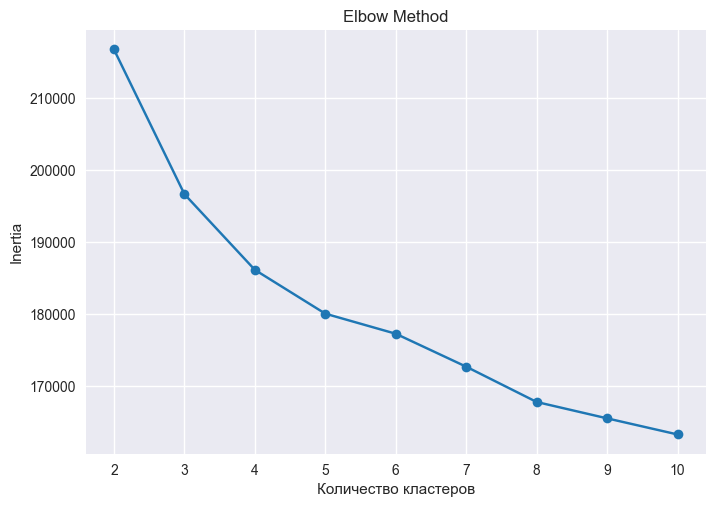

In [353]:
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Количество кластеров")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [354]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_processed)
    score = silhouette_score(X_processed, labels)
    silhouette_scores.append(score)

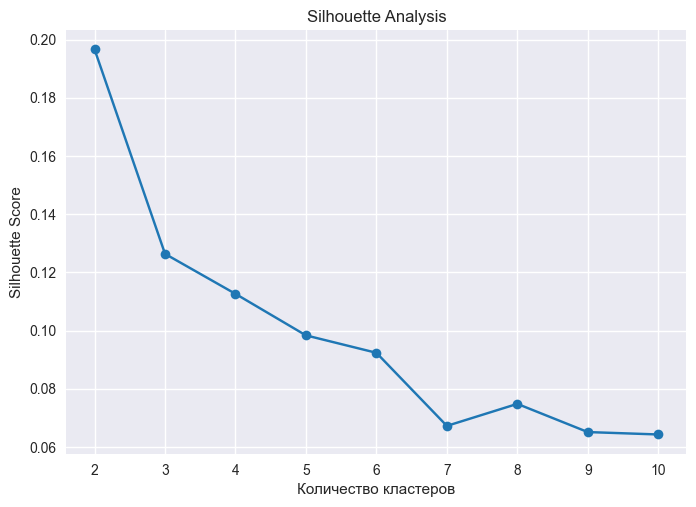

In [355]:
plt.plot(K_range, silhouette_scores, marker="o")
plt.xlabel("Количество кластеров")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

In [356]:
final_model = Pipeline([
    ("preprocess", preprocessor),
    ("kmeans", KMeans(n_clusters=3, random_state=42))
])

final_model.fit(X)

,steps,"[('preprocess', ...), ('kmeans', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [357]:
df["cluster"] = final_model["kmeans"].labels_

In [375]:
score = silhouette_score(X_processed, df["cluster"])
print("Silhouette:", score)

Silhouette: 0.12635736050341248


In [358]:
df["cluster"].value_counts()

cluster
2    1033
1     955
0     772
Name: count, dtype: int64

In [359]:
cluster_profile = df.groupby("cluster")[numeric_cols].mean()
cluster_profile

,ege_avg_budget_full_time,ege_avg_budget_full_time_no_special_rights_no_target_quota,ege_avg_paid_full_time,ege_min_avg_full_time,olympiad_final_winners_admitted_no_exams,school_olympiad_winners_admitted_no_exams,target_admission_count_full_time,target_admission_share_full_time,masters_share_in_total_contingent,masters_admitted_from_other_orgs_share_full_time,...,pcs_internet_share,income_total,income_nonbudget,income_nonbudget_share,income_federal_budget_share,income_regional_local_budget_share,income_edu_share_total,income_research_share_total,nonbudget_share_in_edu_income,nonbudget_share_in_research_income
cluster,,,,,,,,,,,,,,,,,,,,,
0,10.071995,8.258523,44.055311,36.148640,0.173575,0.027202,0.077720,0.094391,5.175091,21.111231,...,96.575453,1.441607e+05,1.325435e+05,93.818238,3.633407,2.548381,81.337448,8.560505,94.960712,80.767422
1,70.813916,70.461403,61.355047,48.596733,4.753927,19.456545,110.589529,7.648796,11.027843,35.778262,...,88.059079,2.987442e+06,1.211901e+06,39.984209,58.575581,1.440492,72.356220,10.997382,35.010785,63.943895
2,66.105779,65.511491,54.253601,49.449874,0.286544,0.280736,35.112294,6.384802,7.220813,36.629719,...,86.862120,6.107857e+05,1.865908e+05,27.744763,61.034201,11.221026,78.560513,5.168161,25.181491,50.423950


In [360]:
cluster_profile.to_csv("cluster_profile.csv")

Вывод:
- кластер 0 – исследовательские лидеры
- кластер 1 – сильные региональные
- кластер 2 – преимущественно образовательные
Модель разделяет уровень научной интенсивности и структурную модель развития

In [361]:
pd.crosstab(df["cluster"], df["federal_district"], normalize="index") * 100

federal_district,Дальневосточный,Приволжский,Северо-Западный,Северо-Кавказский,Сибирский,Уральский,Центральный,Южный
cluster,,,,,,,,
0,1.813472,11.787565,12.046632,7.124352,6.476684,5.310881,45.336788,10.103627
1,2.722513,18.010471,12.879581,2.827225,16.125654,6.178010,32.774869,8.481675
2,8.615682,17.909003,9.486931,7.357212,10.551791,8.518877,30.977735,6.582769


Вывод:
- Кластер 0 сильно центрирован на Центральном федеральном округе, значит высокая доля московских и околомосковских вузов и географический перекос
- Кластер 1 более сбалансированный кластер, центральный округ уже не доминирует, заметно больше Сибири, меньше Северного Кавказа
- Кластер 2 наиболее «географически распределён»

In [362]:
pd.crosstab(
    df["cluster"],
    df["year"],
    normalize="index"
) * 100

year,2015,2020,2021,2022
cluster,,,,
0,26.943005,25.129534,23.704663,24.222798
1,23.350785,25.968586,25.130890,25.549738
2,27.202323,23.814134,24.782188,24.201355


Вывод:
- кластер 0 – лёгкое снижение доли после 2015 года.
- кластер 1 – усиливается после 2015
- кластер 2 – снижается к 2020, затем стабилизируется

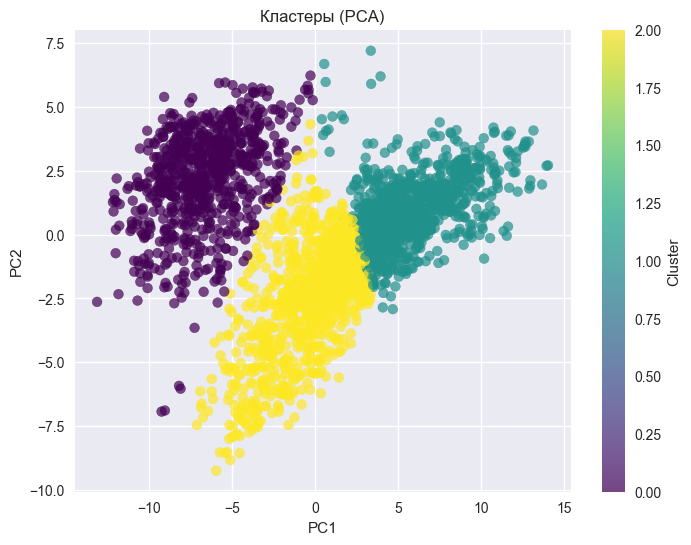

In [363]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["cluster"],
    cmap="viridis",
    s=50,
    alpha=0.7
)

plt.colorbar(label="Cluster")
plt.title("Кластеры (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [372]:
print("Объяснённая дисперсия:", pca.explained_variance_ratio_.sum())

Объяснённая дисперсия: 0.36948548952448546


## Kmeans с PCA

In [368]:
model = Pipeline([
    ("preprocess", preprocessor),
    ("pca", PCA(n_components=3)),
    ("kmeans", KMeans(n_clusters=3, random_state=42))
])

In [369]:
model.fit(X)

,steps,"[('preprocess', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [370]:
df["cluster_pca"] = model["kmeans"].labels_

In [371]:
pca_step = model["pca"]
print("Объяснённая дисперсия:", pca_step.explained_variance_ratio_.sum())

Количество компонент: 3
Объяснённая дисперсия: 0.42028386921515115


In [ ]:
X_processed = model["preprocess"].transform(X)
X_pca = model["pca"].transform(X_processed)

In [373]:
score = silhouette_score(X_pca, df["cluster_pca"])
print("Silhouette (с PCA):", score)

Silhouette (с PCA): 0.477114812102312


PCA улучшил модель

In [376]:
df["cluster_pca"].value_counts()

cluster_pca
1    1010
2     974
0     776
Name: count, dtype: int64

In [377]:
(df["cluster_pca"].value_counts(normalize=True) * 100).round(2)

cluster_pca
1    36.59
2    35.29
0    28.12
Name: proportion, dtype: float64

Вывод: Кластеры достаточно сбалансированны

In [378]:
pd.crosstab(
    df["cluster_pca"],
    df["year"],
    normalize="index"
) * 100

year,2015,2020,2021,2022
cluster_pca,,,,
0,26.675258,25.128866,23.840206,24.355670
1,22.871287,25.742574,25.247525,26.138614
2,28.131417,23.921971,24.537988,23.408624


Вывод:
- Кластеры не определяются годом
- Кластеры имеют практически равномерное распределение

In [379]:
pd.crosstab(
    df["cluster_pca"],
    df["federal_district"],
    normalize="index"
) * 100

federal_district,Дальневосточный,Приволжский,Северо-Западный,Северо-Кавказский,Сибирский,Уральский,Центральный,Южный
cluster_pca,,,,,,,,
0,1.804124,11.855670,11.984536,7.087629,6.443299,5.283505,45.489691,10.051546
1,2.871287,18.217822,12.673267,2.772277,15.940594,6.336634,32.772277,8.415842
2,8.829569,17.659138,9.548255,7.700205,10.472279,8.521561,30.698152,6.570842


Вывод:
- География влияет, но не доминирует
- Нет "чисто географических" кластеров
- Кластеры смешанные

In [380]:
pd.crosstab(
    df["cluster_pca"],
    df["type"],
    normalize="index"
) * 100

type,"Верховный суд Российской Федерации, Высший арбитражный суд Российской Федерации",Министерство здравоохранения Российской Федерации,Министерство здравоохранения и социального развития Российской Федерации,Министерство иностранных дел Российской Федерации,Министерство культуры Российской Федерации,Министерство науки и высшего образования Российской Федерации,Министерство образования и науки Российской Федерации,Министерство просвещения Российской Федерации,Министерство сельского хозяйства Российской Федерации,Министерство спорта Российской Федерации,...,Российская академия наук,Российская академия художеств,"Федеральная служба по интеллектуальной собственности, патентам и товарным знакам",Федеральная таможенная служба,Федеральное агентство воздушного транспорта,Федеральное агентство железнодорожного транспорта,Федеральное агентство морского и речного транспорта,Федеральное агентство по рыболовству,Федеральное агентство связи,Частные образовательные организации
cluster_pca,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.128866,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,94.974227
1,0.000000,8.118812,1.683168,0.396040,0.000000,48.316832,17.227723,4.851485,8.316832,0.297030,...,0.000000,0.000000,0.000000,0.000000,0.099010,2.772277,0.39604,0.891089,0.792079,1.782178
2,0.410678,5.646817,2.977413,0.410678,18.377823,16.016427,8.932238,5.133470,13.449692,4.004107,...,0.102669,0.410678,0.308008,0.410678,1.129363,0.513347,1.74538,1.129363,0.821355,2.464066


Вывод:
- Кластер 0 — это практически полностью частные вузы
- Кластер 1 – крупный массив классических государственных вузов
- Кластер 2 – государственные, но более отраслевые и специализированные университеты (аграрные, культурные, медицинские, спортивные, ведомственные)

In [382]:
cluster_profile_pca = df.groupby("cluster_pca")[numeric_cols].mean()
cluster_profile_pca

,ege_avg_budget_full_time,ege_avg_budget_full_time_no_special_rights_no_target_quota,ege_avg_paid_full_time,ege_min_avg_full_time,olympiad_final_winners_admitted_no_exams,school_olympiad_winners_admitted_no_exams,target_admission_count_full_time,target_admission_share_full_time,masters_share_in_total_contingent,masters_admitted_from_other_orgs_share_full_time,...,pcs_internet_share,income_total,income_nonbudget,income_nonbudget_share,income_federal_budget_share,income_regional_local_budget_share,income_edu_share_total,income_research_share_total,nonbudget_share_in_edu_income,nonbudget_share_in_research_income
cluster_pca,,,,,,,,,,,,,,,,,,,,,
0,10.395606,8.591482,44.223466,36.251108,0.172680,0.027062,0.078608,0.094227,5.240580,21.417693,...,96.582191,1.482115e+05,1.349021e+05,93.791637,3.686082,2.522307,81.295979,8.555915,94.989781,80.842590
1,70.520525,70.082535,61.209713,48.624723,4.539604,18.449505,106.236634,7.438188,11.040861,36.111149,...,88.287564,2.873935e+06,1.160176e+06,39.417772,58.989188,1.593248,72.526485,10.744238,34.608901,64.215277
2,66.116448,65.594702,53.911211,49.442012,0.257700,0.243326,35.507187,6.557782,6.948563,36.152177,...,86.512341,5.929716e+05,1.806731e+05,27.390842,60.937906,11.671304,78.755934,5.091222,24.733460,49.194589


In [384]:
cluster_profile_pca.to_csv("cluster_profile_pca.csv")

Вывод:
- Кластер 0 – образовательные частные вузы, кластер с минимальной научной активностью.
- Кластер 1 – классические государственные университеты, «массовый» сегмент госвузов
- Кластер 2 – исследовательские и отраслевые лидеры

In [ ]:
cluster_profile = df.groupby("cluster_pca")[numeric_cols].mean()
overall_mean = df[numeric_cols].mean()
cluster_diff = cluster_profile - overall_mean

In [ ]:
scaler = StandardScaler()
cluster_z = pd.DataFrame(
    scaler.fit_transform(cluster_profile),
    columns=numeric_cols,
    index=cluster_profile.index
)

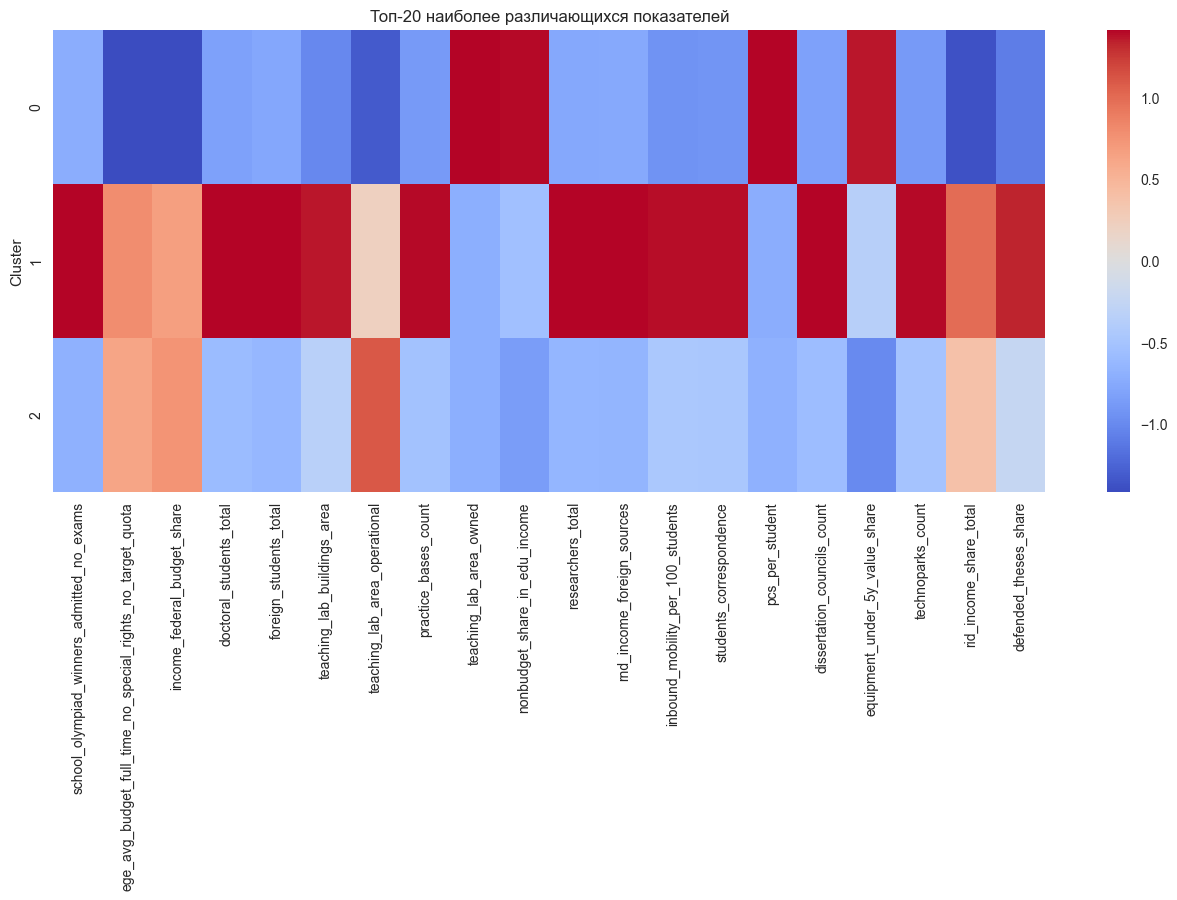

In [388]:
feature_variation = cluster_z.var().sort_values(ascending=False)
top_features = feature_variation.head(20).index

plt.figure(figsize=(16, 6))
sns.heatmap(
    cluster_z[top_features],
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Топ-20 наиболее различающихся показателей")
plt.ylabel("Cluster")
plt.show()

Вывод:
- Кластер 0 – преимущественно образовательные (частные) вузы, минимальная научная активность, ориентация на образовательный доход
- Кластер 1 – научно-интенсивные государственные университеты, исследовательский профиль, гранты, НИОКР, публикации
- Кластер 2 – государственные, но более отраслевые / прикладные, могут иметь хорошую инфраструктуру, но не являются публикационными лидерами
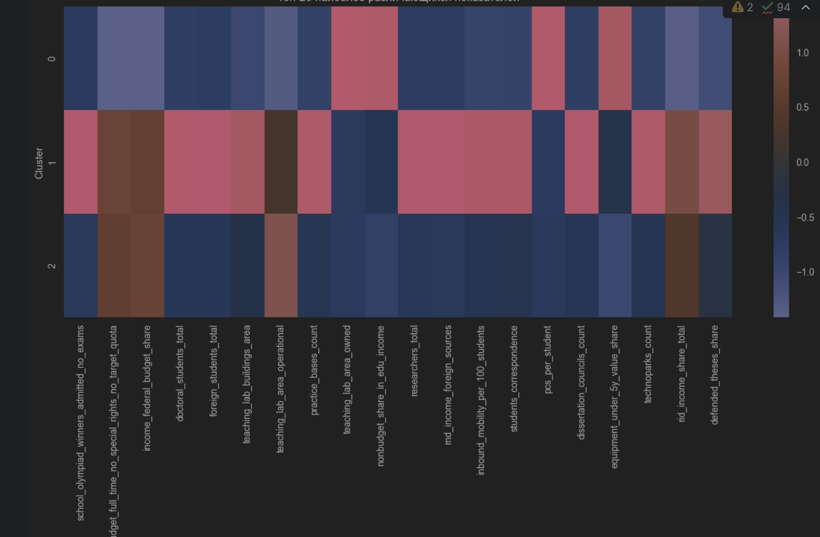

Кластерный анализ выявил трёхкомпонентную структуру высшего образования: образовательный частный сектор, научно-интенсивные исследовательские университеты и прикладные государственные организации с развитой инфраструктурой.